In [1]:
import sys
import os
import importlib
import anndata as ad
import pandas as pd
import scanpy as sc
import squidpy as sq
import logging

/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN_USE_SPARSE_ARRAY = Version(anndata.

In [2]:
sys.path.append(os.path.abspath("/Users/lakshmi_nccs/Desktop/NCCS/Projects/For_Publication/HNSCC_CosMx6k/helpers/"))
import helpers
importlib.reload(helpers)
import tcell_classifier
importlib.reload(tcell_classifier)

<module 'tcell_classifier' from '/Users/lakshmi_nccs/Desktop/NCCS/Projects/For_Publication/HNSCC_CosMx6k/helpers/tcell_classifier.py'>

In [28]:
res_dir = "/Users/lakshmi_nccs/Desktop/NCCS/Projects/Cosmx6k/results/final/P4/Rep"
if not (os.path.exists(res_dir)):
    os.makedirs(res_dir)

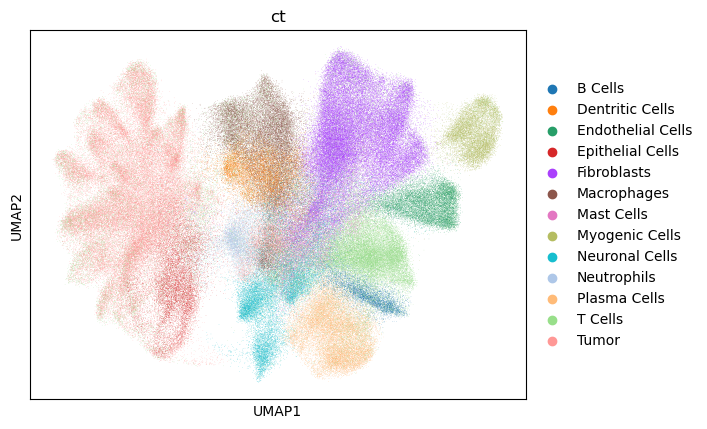

In [36]:
res = 2
ex = "all"
adata = ad.read_h5ad("/Users/lakshmi_nccs/Desktop/NCCS/Projects/Cosmx6k/results/final/P1/" + ex + "_adata_res_" + str(res) + "_hier_annot_resp.h5ad")
cd8s = ad.read_h5ad("/Users/lakshmi_nccs/Desktop/NCCS/Projects/Cosmx6k/results/final/P3/cd8_tcells_dis_tn_tum.h5ad")
sc.pl.umap(adata, color = ['ct'])

In [37]:
adata_merged_obs = adata.obs.merge(
    cd8s.obs[['cell', 'tcell_type_resolved','T_subtypes_l1', 'spatial_bin', 'Distance_to_Tumor']],  # only the columns you want
    on='cell',
    how='left'  # keep all original cells
)
adata.obs = adata_merged_obs.copy()

fib_tumor = adata[adata.obs['ct'].isin(['Fibroblasts', 'Tumor'])].copy()

tcells = adata[adata.obs['ct'] == 'T Cells'].copy()
tcells = tcells[tcells.obs['tcell_type_resolved'] == 'CD4- CD8+'].copy()

adata_sub = fib_tumor.concatenate(tcells)
adata_sub.write_h5ad(res_dir+"adata_T_Tum_Fib.h5ad")

/opt/anaconda3/envs/bioinformatics/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
/var/folders/j3/kfzrbbb92cjgcnjtb19t61pm0000gn/T/ipykernel_77030/224898294.py:13: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html


In [38]:
adata_sub = ad.read_h5ad(res_dir+"adata_T_Tum_Fib.h5ad")
adata_sub = adata_sub[adata_sub.obs['TumorType'].isin(["Post-NIVO Primary"])].copy()
spat_bins = ['Q0: TN', 'Q1: 0-250', 'Q2: 250-500', 'Q3: 500-800', 'Q4: 800+']
for i in range(0,5):
    bbin = spat_bins[i]
    print("LR of T Cells in " + bbin + " and Fibroblasts")
    neibs = helpers.get_LR_neibs_adata(adata_sub, bbin, "Fibroblasts")
    print(neibs)
    if neibs is not None and neibs.n_obs > 0:
        merged_lr = helpers.get_LR_df(neibs, bbin)
        merged_lr.to_csv(res_dir+"LR_T_Q" + str(i) + "_Fibro.csv")


LR of T Cells in Q0: TN and Fibroblasts
TN_status:Fibroblasts
Not TN of Fibroblasts    3061
TN of Fibroblasts         347
Name: count, dtype: int64
TN_status:T Cells
Not TN of T Cells    10738
TN of T Cells          402
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 749 × 6000
    obs: 'cell', 'cell_ID', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD3', 'Max.CD3', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Run_Tissue_name', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes

/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: I

LR of T Cells in Q1: 0-250 and Fibroblasts
TN_status:Fibroblasts
Not TN of Fibroblasts    547
TN of Fibroblasts        313
Name: count, dtype: int64
TN_status:T Cells
Not TN of T Cells    10674
TN of T Cells          466
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 779 × 6000
    obs: 'cell', 'cell_ID', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD3', 'Max.CD3', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Run_Tissue_name', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobe

/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: F

LR of T Cells in Q2: 250-500 and Fibroblasts
TN_status:Fibroblasts
Not TN of Fibroblasts    543
TN of Fibroblasts        347
Name: count, dtype: int64
TN_status:T Cells
Not TN of T Cells    10653
TN of T Cells          487
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 834 × 6000
    obs: 'cell', 'cell_ID', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD3', 'Max.CD3', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Run_Tissue_name', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negpro

/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: I

LR of T Cells in Q3: 500-800 and Fibroblasts
TN_status:Fibroblasts
Not TN of Fibroblasts    322
TN of Fibroblasts        161
Name: count, dtype: int64
TN_status:T Cells
Not TN of T Cells    10909
TN of T Cells          231
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 392 × 6000
    obs: 'cell', 'cell_ID', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD3', 'Max.CD3', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Run_Tissue_name', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negpro

/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: I

LR of T Cells in Q4: 800+ and Fibroblasts
TN_status:Fibroblasts
Not TN of Fibroblasts    351
TN of Fibroblasts        100
Name: count, dtype: int64
TN_status:T Cells
Not TN of T Cells    11027
TN of T Cells          113
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 213 × 6000
    obs: 'cell', 'cell_ID', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD3', 'Max.CD3', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Run_Tissue_name', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes

/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: I

In [39]:
print("LR of T Cells in Q0 and Tumor")
adata_sub = ad.read_h5ad(res_dir+"adata_T_Tum_Fib.h5ad")
adata_sub = adata_sub[adata_sub.obs['TumorType'].isin(["Post-NIVO Primary"])].copy()
neibs = helpers.get_LR_neibs_adata(adata_sub, 'Q0: TN', "Tumor")
merged_lr = helpers.get_LR_df(neibs, 'Q0: TN')
merged_lr.to_csv(res_dir+"LR_T_Q0_Tum.csv")

LR of T Cells in Q0 and Tumor
TN_status:Tumor
TN of Tumor    3408
Name: count, dtype: int64
TN_status:T Cells
Not TN of T Cells    11360
TN of T Cells         7537
Name: count, dtype: int64


/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future de

In [40]:
print("LR of Tumor and Fibroblasts")
adata_sub = ad.read_h5ad(res_dir+"adata_T_Tum_Fib.h5ad")
adata_sub = adata_sub[adata_sub.obs['TumorType'].isin(["Post-NIVO Primary"])].copy()
neibs = helpers.get_LR_neibs_adata(adata_sub, 'Tumor', "Fibroblasts")
merged_lr = helpers.get_LR_df(neibs, '')
merged_lr.to_csv(res_dir+"LR_Tum_Fibro.csv")

LR of Tumor and Fibroblasts
TN_status:Fibroblasts
Not TN of Fibroblasts    16949
TN of Fibroblasts         1948
Name: count, dtype: int64
TN_status:Tumor
Not TN of Tumor    9591
TN of Tumor        1549
Name: count, dtype: int64


/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: I